## RL Leanring - Q path finder concepts

In [2]:
# Installing libs
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install gymnasium

  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl (12.3 MB)



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 23.4 MB/s  0:00:00
Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl (7.1 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [p


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl (9.7 MB)
Using cached tzdata-2026.1-py2.py3-none-any.whl (348 kB)

   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
 


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/952.1 kB ? eta -:--:--
   ---------------------------------------- 952.1/952.1 kB 20.7 MB/s  0:00:00
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)

   ------------------------------ --------- 3/4 [gymnasium]
   ------------------------------ --------- 3/4 [gymnasium]
   ------------------------------ --------- 3/4 [gymnasium]
   ------------------------------ --------- 3/4 [gymnasium]
   ------------------------------ --------- 3/4 [gymnasium]
   ------------------------------ --------- 3/4 [gymnasium]
   ---------------------------------------- 4/4 [gymnasium]




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Buiding a world for our path
- define path to move like a layout
- state : where Am i now?
- Action decidion : where to move in the path
- Decidion result : does my move is in the right path/wrong path(+10,-10,-1)
- for this tutotrial we use Frozen lake grid(4x4)

In [3]:
# Importing libs
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gymnasium as gym
import random


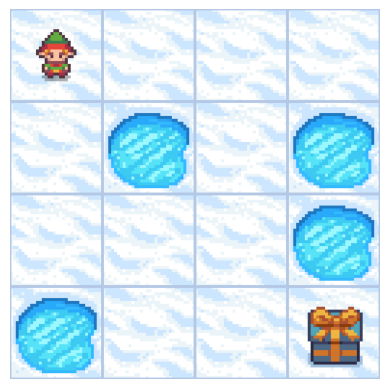

Total number of states: 16
Total number of actions: 4


In [5]:
#creating an env - Frozenlake-v1
env= gym.make('FrozenLake-v1', desc=None, is_slippery=False, map_name= '4x4', render_mode= 'rgb_array')

#Resetting the env
obs, info= env.reset()

#plotting the grid
plt.imshow(env.render())
plt.axis('off')
plt.show()

#print observations
print(f'Total number of states: {env.observation_space.n}')
print(f'Total number of actions: {env.action_space.n}')

### Q Table
- A cheat sheet to store the memory of a single agent
- Helps to store state and action values so agent knows at what state, whhich action gives what results
- Hyperparameters: Learning rate, Discount Factor, Epsilon

In [6]:
# Intiall Q table for our agent
q_table= np.zeros((env.observation_space.n, env.action_space.n))
print(q_table)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


$$New\ Q(s,a) = Q(s,a) + \alpha [Reward + \gamma \max Q(s',a') - Q(s,a)]$$
#### The new value for this move is the old value PLUS a bit of the reward we just got and the potential reward we see ahead.

In [7]:
learning_rate = 0.8
discount_factor = 0.99
epsilon = 1.0          # Start by exploring 100% of the time
epsilon_decay = 0.001   # Slowly stop exploring as we learn

### Training the agent

In [8]:
#parameters
episodes = 20000 # no of iterations
max_step = 1000 # no of steps in single iteration

for episode in range(episodes):
  obs, info = env.reset()
  done = False

  for step in range(max_step):
    #action Selection
    if random.uniform(0,1) < epsilon:
      action = env.action_space.sample() # random action
    else:
      action = np.argmax(q_table[obs,:]) # use best move in table

    # Action taken
    next_obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    # Update Q table
    best_next_action = np.max(q_table[next_obs,:])

    q_table[obs, action] = q_table[obs, action] + learning_rate * (reward + discount_factor * best_next_action - q_table[obs, action])

    obs = next_obs

    if done:
      break

  #Delay epsilon so it slowly learns over the training
  epsilon = max(epsilon - epsilon_decay, 0.01)

print(f'Training completed')



Training completed


###

In [9]:
# Define the column names based on the action mapping
columns = ['Left (0)', 'Down (1)', 'Right (2)', 'Up (3)']

# Create a DataFrame
df = pd.DataFrame(q_table, columns=columns)

# Add a "State" index for clarity
df.index.name = 'State'

# Display the table
df

,Left (0),Down (1),Right (2),Up (3)
State,,,,
0,0.941480,0.950990,0.950990,0.941480
1,0.941480,0.000000,0.960596,0.950990
2,0.950990,0.970299,0.950990,0.960596
3,0.960596,0.000000,0.912874,0.950366
4,0.950990,0.960596,0.000000,0.941480
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.980100,0.000000,0.960596
7,0.000000,0.000000,0.000000,0.000000
8,0.960596,0.000000,0.970299,0.950990


### Eval using Q table

Finding Path Mission:


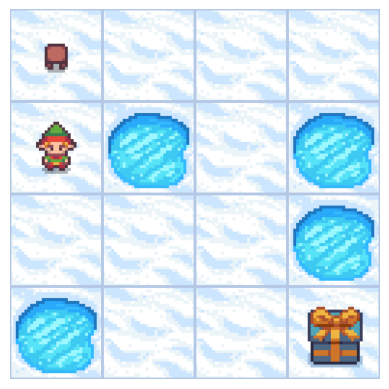

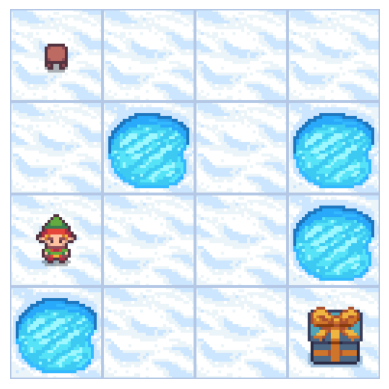

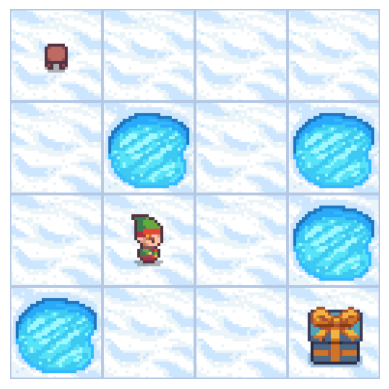

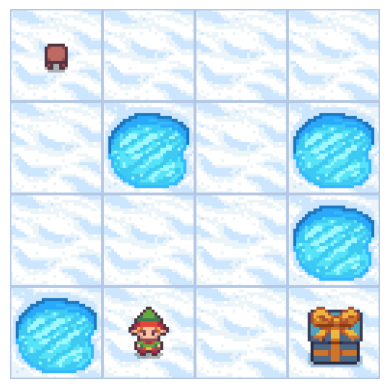

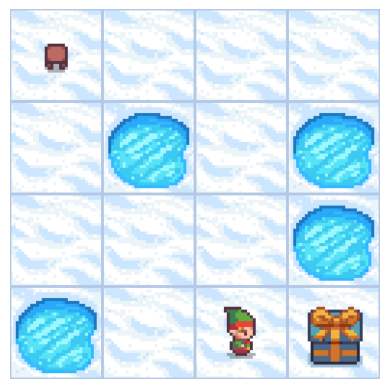

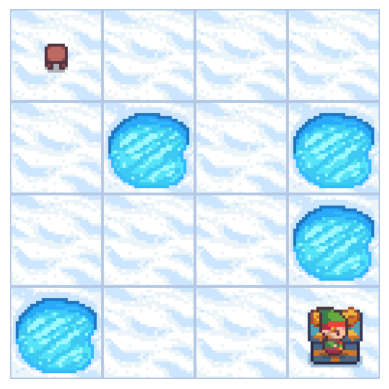

Mission completed in 6 steps
Mission Success: Agent Home


In [10]:
#resetting the state
obs, info = env.reset()
done = False
total_reward = 0
step_count = 0

print('Finding Path Mission:')

while not done:
#picking only best values from Q table
  action = np.argmax(q_table[obs,:])

  #Take next step
  next_obs, reward, terminated, truncated, info = env.step(action)

  #plot
  plt.imshow(env.render())
  plt.axis('off')
  plt.show()

  obs = next_obs
  done = terminated or truncated
  total_reward += reward
  step_count += 1

print(f'Mission completed in {step_count} steps')

if total_reward == 1:
  print('Mission Success: Agent Home')
else:
  print('Mission Failed: Agent Expired')




In [12]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
